# Module 5 — Model Predictions of Changes in Global O3
### B4 Chemistry in the Atmosphere · companion notebook

The key conceptual point of this module: a large *local* (altitude-specific) percentage change
in ozone can correspond to a small change in the *total column*, if it happens at an altitude
where the ozone number density is low -- whereas the same percentage change lower down, where
most of the ozone column actually sits, has a much bigger effect on the column total. This is
the crux of why upper-stratospheric gas-phase catalytic loss cannot explain the Antarctic ozone
hole (a lower-stratospheric phenomenon).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## A realistic-shaped ozone profile

We reuse a Gaussian-ish number-density profile peaking near 25 km (as in Module 3's notebook),
and compute its column (in Dobson Units) as a baseline.

Baseline column = 326.1 DU


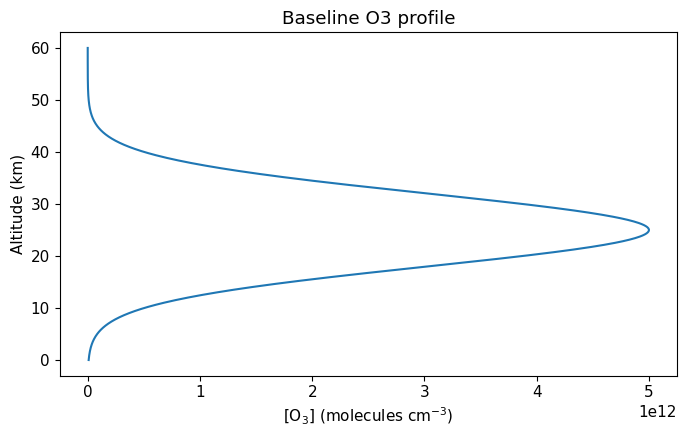

In [2]:
def n_O3(z_km, peak=5e12, z_peak=25, width=7):
    return peak * np.exp(-0.5*((z_km - z_peak)/width)**2)

z = np.linspace(0, 60, 600)
dz_cm = (z[1]-z[0]) * 1e5   # km -> cm
profile = n_O3(z)
column_cm2 = np.sum(profile) * dz_cm
DU = 2.69e16
print(f"Baseline column = {column_cm2/DU:.1f} DU")

plt.figure()
plt.plot(profile, z)
plt.xlabel('[O$_3$] (molecules cm$^{-3}$)')
plt.ylabel('Altitude (km)')
plt.title('Baseline O3 profile')
plt.tight_layout()
plt.show()

## Perturbation 1 — a 20% loss localised at 40 km (upper stratosphere)

This mimics the CFC/ClOx-driven loss discussed in the notes: large % change, but at an altitude
where [O3] itself is relatively low (we're past the profile's peak).

In [3]:
def apply_gaussian_perturbation(z, profile, pct_loss, z_center, width=5):
    weight = np.exp(-0.5*((z - z_center)/width)**2)   # how much of the % loss applies at each z
    return profile * (1 - pct_loss * weight)

perturbed_40 = apply_gaussian_perturbation(z, profile, pct_loss=0.20, z_center=40, width=5)
col_40 = np.sum(perturbed_40) * dz_cm / DU
col_base = np.sum(profile) * dz_cm / DU

print(f"Baseline column:            {col_base:.1f} DU")
print(f"After 40 km, 20% local loss: {col_40:.1f} DU  (change: {100*(col_40-col_base)/col_base:.2f}%)")

Baseline column:            326.1 DU
After 40 km, 20% local loss: 317.8 DU  (change: -2.54%)


## Perturbation 2 — the same 20% loss, but localised at 15 km (lower stratosphere, ozone-hole-like)

After 15 km, 20% local loss: 306.8 DU  (change: -5.92%)


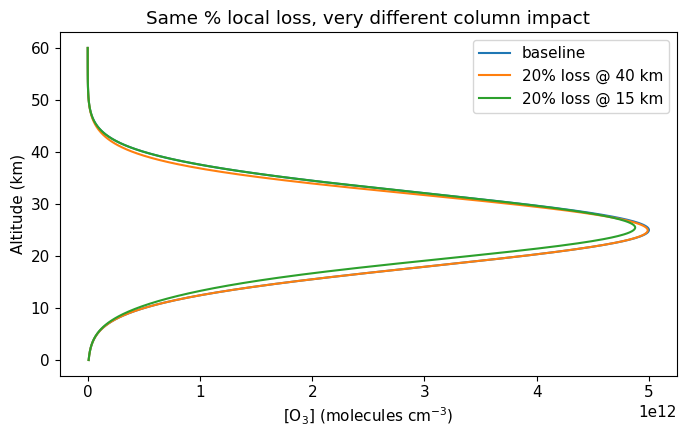

In [4]:
perturbed_15 = apply_gaussian_perturbation(z, profile, pct_loss=0.20, z_center=15, width=5)
col_15 = np.sum(perturbed_15) * dz_cm / DU

print(f"After 15 km, 20% local loss: {col_15:.1f} DU  (change: {100*(col_15-col_base)/col_base:.2f}%)")

plt.figure()
plt.plot(profile, z, label='baseline')
plt.plot(perturbed_40, z, label='20% loss @ 40 km')
plt.plot(perturbed_15, z, label='20% loss @ 15 km')
plt.xlabel('[O$_3$] (molecules cm$^{-3}$)')
plt.ylabel('Altitude (km)')
plt.legend()
plt.title('Same % local loss, very different column impact')
plt.tight_layout()
plt.show()

**This is the whole point of the module**: the 15 km perturbation removes far more *column*
ozone than the 40 km one, for an identical 20% local change, simply because more of the total
ozone column sits at 15 km than at 40 km in this profile. The real Antarctic ozone hole involves
much larger *local* losses (~50-90%) concentrated in the lower stratosphere -- which is why it
produces such a dramatic drop in total column (>300 DU to ~100 DU) that upper-stratospheric
gas-phase chemistry alone cannot reproduce.

## Exercises

1. **Threshold search.** Holding the perturbation width fixed at 5 km, find the altitude at which
   a 20% local loss produces the *largest* column change. Does it coincide with the peak of the
   baseline profile? Should it?

2. **Matching the real ozone hole.** The real Antarctic ozone hole takes the column from ~300 DU
   to ~100 DU (a ~67% reduction) within a few weeks. Adjust `pct_loss` and `z_center`/`width` in
   the lower-stratosphere perturbation to reproduce a comparable column change, and report what
   *local* percentage loss that requires at ~15-20 km.

3. **Multi-family budget.** Implement the multi-term odd-oxygen budget equation from the notes as
   a function `dOx_dt(O, O3, NO2, HO2, ClO, BrO, ...)`, using illustrative rate constants, and
   rank the terms by magnitude for representative concentrations. Which terms dominate at 40 km
   vs 20 km, based on what you already calculated in Module 4's exercises?